In [1]:
!pip install yfinance

In [3]:
!pip install --upgrade pip setuptools wheel

In [2]:
import yfinance as yf

sp500 = yf.download("^GSPC", start="2016-03-21", end="2026-03-21", auto_adjust=False)
print(sp500.head())
print(sp500.columns)

C:\Users\Asus\anaconda4\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[*********************100%***********************]  1 of 1 completed

Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date                                                                          
2016-03-21  2051.600098  2051.600098  2053.909912  2043.140015  2047.880005   
2016-03-22  2049.800049  2049.800049  2056.600098  2040.569946  2048.639893   
2016-03-23  2036.709961  2036.709961  2048.550049  2034.859985  2048.550049   
2016-03-24  2035.939941  2035.939941  2036.040039  2022.489990  2032.479980   
2016-03-28  2037.050049  2037.050049  2042.670044  2031.959961  2037.890015   

Price           Volume  
Ticker           ^GSPC  
Date                    
2016-03-21  3376600000  
2016-03-22  3418460000  
2016-03-23  3639510000  
2016-03-24  3407720000  
2016-03-28  2809090000  
MultiIndex([('Adj Close', '^GSPC'),
            (    'Close', '^GSPC'),
            (     'High', '^GSPC'),
            (      'Low', '^GSPC'),
            (     'Open

In [3]:
import pandas as pd
import numpy as np

df = sp500.copy()

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df.reset_index()

df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

df = df.rename(columns={'Close': 'Price'})

df = df.sort_values('Date').reset_index(drop=True)

print(df.head())
print(df.columns)
print(df.shape)
print(df.isnull().sum())

        Date         Open         High          Low        Price      Volume
0 2016-03-21  2047.880005  2053.909912  2043.140015  2051.600098  3376600000
1 2016-03-22  2048.639893  2056.600098  2040.569946  2049.800049  3418460000
2 2016-03-23  2048.550049  2048.550049  2034.859985  2036.709961  3639510000
3 2016-03-24  2032.479980  2036.040039  2022.489990  2035.939941  3407720000
4 2016-03-28  2037.890015  2042.670044  2031.959961  2037.050049  2809090000
Index(['Date', 'Open', 'High', 'Low', 'Price', 'Volume'], dtype='object')
(2515, 6)
Date      0
Open      0
High      0
Low       0
Price     0
Volume    0
dtype: int64


In [4]:

df['Price_lag1'] = df['Price'].shift(1)
df['Price_lag2'] = df['Price'].shift(2)
df['Price_lag3'] = df['Price'].shift(3)


df_lag = df[['Date', 'Price', 'Price_lag1', 'Price_lag2', 'Price_lag3']].dropna().copy()

df_full = df[['Date', 'Price', 'Open', 'High', 'Low', 'Volume',
              'Price_lag1', 'Price_lag2', 'Price_lag3']].dropna().copy()

print("Lag-only dataset shape:", df_lag.shape)
print("Full-feature dataset shape:", df_full.shape)

Lag-only dataset shape: (2512, 5)
Full-feature dataset shape: (2512, 9)


In [5]:

train_size_lag = int(len(df_lag) * 0.8)
train_lag = df_lag.iloc[:train_size_lag].copy()
test_lag = df_lag.iloc[train_size_lag:].copy()

train_size_full = int(len(df_full) * 0.8)
train_full = df_full.iloc[:train_size_full].copy()
test_full = df_full.iloc[train_size_full:].copy()

print("Lag-only train:", train_lag.shape)
print("Lag-only test:", test_lag.shape)
print("Full-feature train:", train_full.shape)
print("Full-feature test:", test_full.shape)

Lag-only train: (2009, 5)
Lag-only test: (503, 5)
Full-feature train: (2009, 9)
Full-feature test: (503, 9)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# lin lag
X_train_lr_lag = train_lag[['Price_lag1', 'Price_lag2', 'Price_lag3']]
y_train_lr_lag = train_lag['Price']

X_test_lr_lag = test_lag[['Price_lag1', 'Price_lag2', 'Price_lag3']]
y_test_lr_lag = test_lag['Price']

lr_lag = LinearRegression()
lr_lag.fit(X_train_lr_lag, y_train_lr_lag)
pred_lr_lag = lr_lag.predict(X_test_lr_lag)

rmse_lr_lag = np.sqrt(mean_squared_error(y_test_lr_lag, pred_lr_lag))
mae_lr_lag = mean_absolute_error(y_test_lr_lag, pred_lr_lag)

print("LR lag-only RMSE:", rmse_lr_lag)
print("LR lag-only MAE:", mae_lr_lag)


# lin full
X_train_lr_full = train_full[['Price_lag1', 'Price_lag2', 'Price_lag3', 'Open', 'High', 'Low', 'Volume']]
y_train_lr_full = train_full['Price']

X_test_lr_full = test_full[['Price_lag1', 'Price_lag2', 'Price_lag3', 'Open', 'High', 'Low', 'Volume']]
y_test_lr_full = test_full['Price']

lr_full = LinearRegression()
lr_full.fit(X_train_lr_full, y_train_lr_full)
pred_lr_full = lr_full.predict(X_test_lr_full)

rmse_lr_full = np.sqrt(mean_squared_error(y_test_lr_full, pred_lr_full))
mae_lr_full = mean_absolute_error(y_test_lr_full, pred_lr_full)

print("LR full-feature RMSE:", rmse_lr_full)
print("LR full-feature MAE:", mae_lr_full)

LR lag-only RMSE: 57.598068043847725
LR lag-only MAE: 39.57403124798988
LR full-feature RMSE: 18.995089364503627
LR full-feature MAE: 13.358857449614987


In [8]:
from statsmodels.tsa.arima.model import ARIMA

train_series_lag = train_lag['Price'].astype(float)
test_series_lag = test_lag['Price'].astype(float)

model_arima_lag = ARIMA(train_series_lag, order=(1,1,1))
fit_arima_lag = model_arima_lag.fit()

rolling_preds_arima_lag = []
current_res = fit_arima_lag

for y in test_series_lag:
    pred = current_res.forecast(steps=1)
    rolling_preds_arima_lag.append(float(pred.iloc[0] if hasattr(pred, "iloc") else pred[0]))
    current_res = current_res.append([y], refit=False)

rmse_arima_lag = np.sqrt(mean_squared_error(test_series_lag, rolling_preds_arima_lag))
mae_arima_lag = mean_absolute_error(test_series_lag, rolling_preds_arima_lag)

print("ARIMA lag-only RMSE:", rmse_arima_lag)
print("ARIMA lag-only MAE:", mae_arima_lag)

C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, ca

ARIMA lag-only RMSE: 57.641200190502936
ARIMA lag-only MAE: 39.73931152515951


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

train_full = train_full.copy()
test_full = test_full.copy()

train_full['Volume_scaled'] = train_full['Volume'] / 1e9
test_full['Volume_scaled'] = test_full['Volume'] / 1e9


exog_train = train_full[['Open', 'High', 'Low', 'Volume_scaled']].astype(float)
exog_test = test_full[['Open', 'High', 'Low', 'Volume_scaled']].astype(float)


train_series_full = train_full['Price'].astype(float)
test_series_full = test_full['Price'].astype(float)


model_arimax = SARIMAX(
    train_series_full,
    exog=exog_train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_arimax = model_arimax.fit(disp=False, maxiter=200)


forecast_arimax = fit_arimax.get_forecast(
    steps=len(test_series_full),
    exog=exog_test
)

pred_arimax = forecast_arimax.predicted_mean


rmse_arimax = np.sqrt(mean_squared_error(test_series_full, pred_arimax))
mae_arimax = mean_absolute_error(test_series_full, pred_arimax)

print("ARIMAX full-feature RMSE:", rmse_arimax)
print("ARIMAX full-feature MAE:", mae_arimax)


results_arimax = pd.DataFrame({
    'Date': test_full['Date'].values,
    'Actual': test_series_full.values,
    'ARIMAX_Pred': pred_arimax.values
})

print(results_arimax.head())

C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMAX full-feature RMSE: 18.565104234931002
ARIMAX full-feature MAE: 13.18166663594619
        Date       Actual  ARIMAX_Pred
0 2024-03-19  5178.509766  5170.463094
1 2024-03-20  5224.620117  5212.978624
2 2024-03-21  5241.529785  5249.686918
3 2024-03-22  5234.180176  5234.957676
4 2024-03-25  5218.189941  5224.914656


C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Asus\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [14]:
results_summary = pd.DataFrame({
    'Model': [
        'Linear Regression (lag-only)',
        'ARIMA (lag-only)',
        'Linear Regression (full features)',
        'ARIMAX (full features)'
    ],
    'RMSE': [
        rmse_lr_lag,
        rmse_arima_lag,
        rmse_lr_full,
        rmse_arimax
    ],
    'MAE': [
        mae_lr_lag,
        mae_arima_lag,
        mae_lr_full,
        mae_arimax
    ]
})

print(results_summary)

                               Model       RMSE        MAE
0       Linear Regression (lag-only)  57.598068  39.574031
1                   ARIMA (lag-only)  58.727931  41.001337
2  Linear Regression (full features)  18.995089  13.358857
3             ARIMAX (full features)  18.586229  13.205306


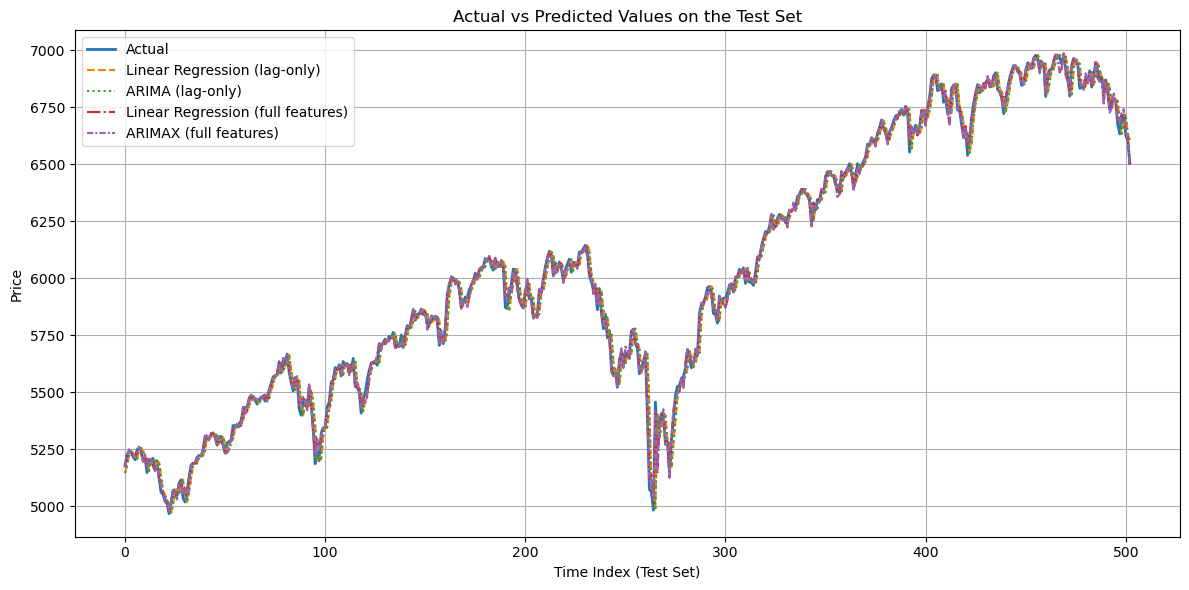

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

results_compare = pd.DataFrame({
    'Date': test_lag['Date'].values,
    'Actual': test_lag['Price'].values,
    'LR_Lag': pred_lr_lag,
    'ARIMA_Lag': rolling_preds_arima_lag
})


results_compare['LR_Full'] = pred_lr_full
results_compare['ARIMAX_Full'] = pred_arimax.values if hasattr(pred_arimax, "values") else pred_arimax

plt.figure(figsize=(12, 6))
plt.plot(results_compare['Actual'].values, label='Actual', linewidth=2)
plt.plot(results_compare['LR_Lag'].values, label='Linear Regression (lag-only)', linestyle='--')
plt.plot(results_compare['ARIMA_Lag'].values, label='ARIMA (lag-only)', linestyle=':')
plt.plot(results_compare['LR_Full'].values, label='Linear Regression (full features)', linestyle='-.')
plt.plot(results_compare['ARIMAX_Full'].values, label='ARIMAX (full features)', linestyle=(0, (3, 1, 1, 1)))

plt.title('Actual vs Predicted Values on the Test Set')
plt.xlabel('Time Index (Test Set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("predictions.png", dpi=300)
plt.show()

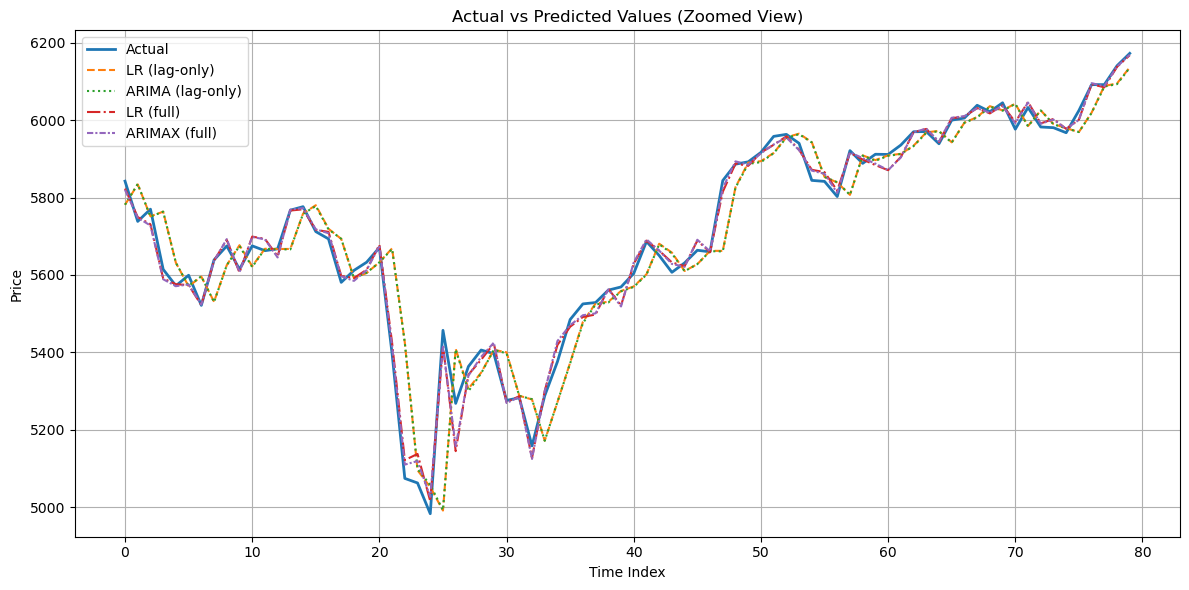

In [11]:
#zoom
start = 240
end = 320

plt.figure(figsize=(12, 6))

plt.plot(results_compare['Actual'].values[start:end], label='Actual', linewidth=2)
plt.plot(results_compare['LR_Lag'].values[start:end], label='LR (lag-only)', linestyle='--')
plt.plot(results_compare['ARIMA_Lag'].values[start:end], label='ARIMA (lag-only)', linestyle=':')
plt.plot(results_compare['LR_Full'].values[start:end], label='LR (full)', linestyle='-.')
plt.plot(results_compare['ARIMAX_Full'].values[start:end], label='ARIMAX (full)', linestyle=(0, (3,1,1,1)))

plt.title('Actual vs Predicted Values (Zoomed View)')
plt.xlabel('Time Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("predictions_zoomed.png", dpi=300)
plt.show()

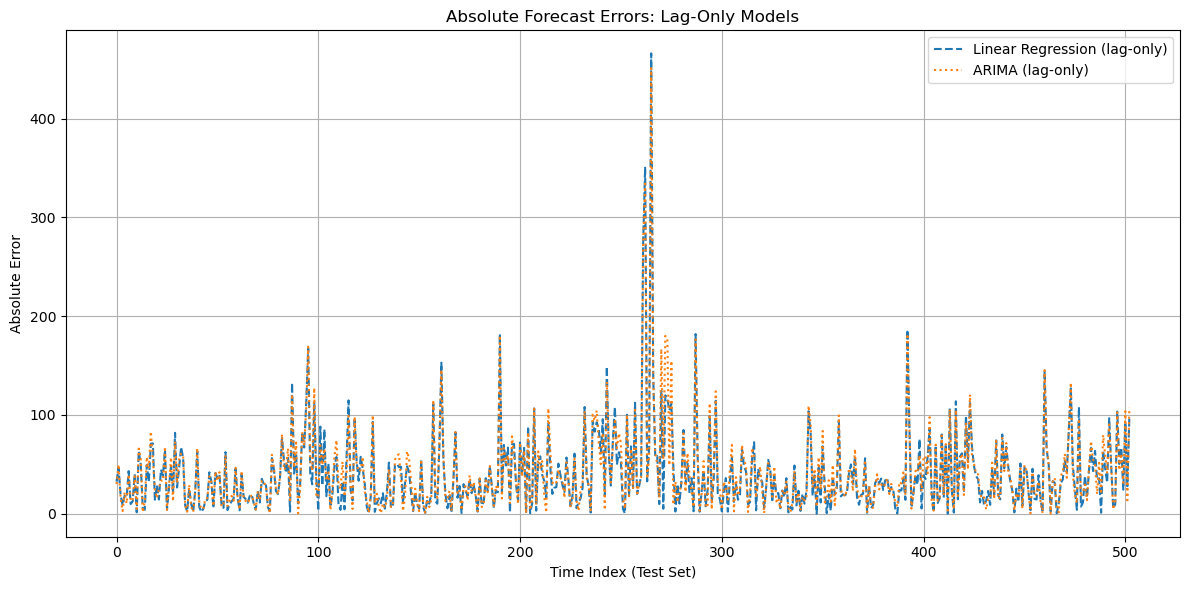

In [18]:
import matplotlib.pyplot as plt
import numpy as np

err_lr_lag = np.abs(results_compare['Actual'] - results_compare['LR_Lag'])
err_arima_lag = np.abs(results_compare['Actual'] - results_compare['ARIMA_Lag'])

plt.figure(figsize=(12, 6))
plt.plot(err_lr_lag.values, label='Linear Regression (lag-only)', linestyle='--')
plt.plot(err_arima_lag.values, label='ARIMA (lag-only)', linestyle=':')

plt.title('Absolute Forecast Errors: Lag-Only Models')
plt.xlabel('Time Index (Test Set)')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("errors_lag_only.png", dpi=300)
plt.show()

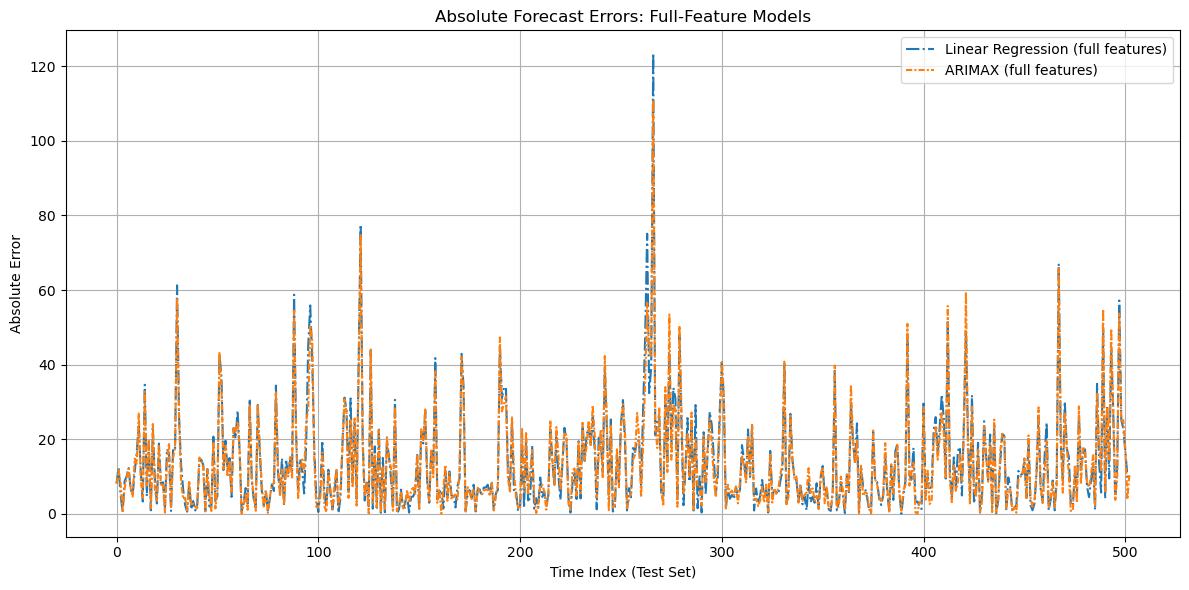

In [12]:
err_lr_full = np.abs(results_compare['Actual'] - results_compare['LR_Full'])
err_arimax_full = np.abs(results_compare['Actual'] - results_compare['ARIMAX_Full'])

plt.figure(figsize=(12, 6))
plt.plot(err_lr_full.values, label='Linear Regression (full features)', linestyle='-.')
plt.plot(err_arimax_full.values, label='ARIMAX (full features)', linestyle=(0, (3, 1, 1, 1)))

plt.title('Absolute Forecast Errors: Full-Feature Models')
plt.xlabel('Time Index (Test Set)')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("errors_full_features.png", dpi=300)
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_lag['Price'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -0.4383398482328441
p-value: 0.9034979149294013


In [14]:
diff_series = train_lag['Price'].diff().dropna()

result_diff = adfuller(diff_series)

print('ADF Statistic (diff):', result_diff[0])
print('p-value (diff):', result_diff[1])

ADF Statistic (diff): -13.994611767347505
p-value (diff): 3.960239607392226e-26
